# AAVSO Report Quality Check

Compares an untransformed AAVSO Extended-format report against the same session with a transform applied (`TRANS=YES` via VPhot's Transform Applier), to see whether the transform improved the check star's agreement with its catalog magnitude and/or reduced scatter.

Assumes a single comparison star + single check star (not an ensemble). Two required inputs: the untransformed AAVSO report and the untransformed session's VPhot **General Report** (per-observation SNR/error and image-quality diagnostics the AAVSO Extended format doesn't carry). A third input, the TA-transformed AAVSO report, is optional — set `AFTER_REPORT_PATH = None` to run accuracy/precision/trend checks on a session with no transform yet (e.g. reduced in only one filter so far); with it set, results show a Before/After comparison instead.

Results are shown in two tables: **Check Stars** (has a known catalog magnitude and a photon-noise floor, so both accuracy and precision are measurable) and **Targets** (no catalog magnitude — precision/scatter and VSX range are the available checks).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
from pathlib import Path
from IPython.display import display, Markdown

In [2]:
BEFORE_REPORT_PATH = "../../../Documents/astrophotography/Photometry/yzboo/AAVSOReport_YZ-Boo_VRB_20260814.txt"
AFTER_REPORT_PATH = "../../../Documents/astrophotography/Photometry/yzboo/AAVSOReport_YZ-Boo_VRB_20260814_TA.txt"
# Set AFTER_REPORT_PATH to None if no transform has been run yet (e.g. a session that's
# only been reduced in one filter so far) -- the notebook then reports accuracy/precision/
# trend for the untransformed data alone, with no Before/After comparison.
# VPhot "General Report" for the (untransformed) session -- gives per-observation Err/SNR
# and image-quality diagnostics that the AAVSO Extended report doesn't carry. The same
# physical exposures underlie both Before and After, so one file covers both.
GENERAL_REPORT_PATH = "../../../Documents/astrophotography/Photometry/yzboo/AAVSOReport_YZ-Boo_VRB_20260814_General.txt"

In [3]:
def parse_notes(notes_str):
    """AAVSO NOTES field is '|KEY=VAL|KEY=VAL|...'."""
    parsed = {}
    if not isinstance(notes_str, str):
        return parsed
    for part in notes_str.strip("|").split("|"):
        if "=" in part:
            key, val = part.split("=", 1)
            parsed[key] = val
    return parsed


def parse_aavso_report(path):
    path = Path(path)
    delim = ","
    header = None
    data_lines = []

    for line in path.read_text().splitlines():
        if not line.strip():
            continue
        if line.startswith("#DELIM="):
            delim = line.split("=", 1)[1].strip()
        elif line.startswith("#NAME" + delim):
            header = line.lstrip("#").split(delim)
        elif line.startswith("#"):
            # Also skips commented-out pre-transform rows a TransformApplier report
            # leaves in place alongside its TRANS=YES replacement rows.
            continue
        else:
            data_lines.append(line.split(delim))

    if header is None:
        raise ValueError(f"Could not find column header line in {path}")

    df = pd.DataFrame(data_lines, columns=header)

    for col in ["DATE", "MAG", "MERR", "CMAG", "KMAG", "AMASS"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    notes = df["NOTES"].apply(parse_notes)
    df["KREFMAG"] = notes.apply(lambda d: float(d["KREFMAG"]) if "KREFMAG" in d else np.nan)
    # Catalog uncertainty of the check star's own reference magnitude -- the natural
    # yardstick for whether an observed Delta is "real" or within the catalog's own noise.
    df["KREFERR"] = notes.apply(lambda d: float(d["KREFERR"]) if "KREFERR" in d else np.nan)
    df["CREFMAG"] = notes.apply(lambda d: float(d["CREFMAG"]) if "CREFMAG" in d else np.nan)
    # KMAG is standardized in ENSEMBLE reports but raw instrumental in single-comp/check
    # reports (matches KMAGINS there) -- KMAGSTD in NOTES is the standardized value in both.
    df["KMAGSTD"] = notes.apply(lambda d: float(d["KMAGSTD"]) if "KMAGSTD" in d else np.nan)
    # KMAGTRAN only appears on TRANS=YES rows (transform-corrected check star mag).
    # KEFF is "the best standardized check-star mag this report can offer": KMAGTRAN
    # when a transform was applied, otherwise KMAGSTD.
    df["KMAGTRAN"] = notes.apply(lambda d: float(d["KMAGTRAN"]) if "KMAGTRAN" in d else np.nan)
    df["KEFF"] = df["KMAGTRAN"].fillna(df["KMAGSTD"])

    return df


def parse_general_report(path):
    """VPhot General Report: tab-delimited, columns are positional (not name-keyed) --
    JD, Filter, Airmass, <target mag>, <check mag>, <comp mag, always 'na'>, Err, SNR,
    FWHM, Skyglow, Max ADU, I.M. Only valid for the single-comp/single-check scope this
    notebook assumes; an ensemble report would have more star-magnitude columns.
    """
    path = Path(path)
    df = pd.read_csv(path, sep="\t")
    df.columns = [
        "JD", "Filter", "Airmass", "TargetMag", "CheckMag", "CompMag",
        "Err", "SNR", "FWHM", "Skyglow", "MaxADU", "IM",
    ]
    for col in df.columns:
        if col != "Filter":
            df[col] = pd.to_numeric(df[col], errors="coerce")
    return df


def attach_general_report(df_aavso, df_general, tolerance_days=0.0001):
    """Join General Report columns onto an AAVSO report by nearest JD within `tolerance_days`,
    matched per filter. The two reports' timestamps are computed independently (not just
    rounded/truncated versions of the same number) and can differ by a few 1e-5 days even
    for the same exposure, so an exact-equality join on rounded JD silently drops rows;
    nearest-within-tolerance is robust to that. 0.0001 days (~8.6s) is well under this
    session's ~70s per-filter cadence.
    """
    cols = ["JD", "Filter", "Err", "SNR", "FWHM", "Skyglow", "MaxADU"]
    parts = []
    for filt, group in df_aavso.groupby("FILT", sort=False):
        gen_f = df_general.loc[df_general["Filter"] == filt, cols].sort_values("JD")
        merged = pd.merge_asof(
            group.sort_values("DATE"), gen_f,
            left_on="DATE", right_on="JD",
            direction="nearest", tolerance=tolerance_days,
        )
        parts.append(merged)
    return pd.concat(parts).sort_index().drop(columns=["JD", "Filter"])

In [4]:
def fetch_vsx_range(star_name):
    """Catalog (max, min) V-band magnitude from AAVSO VSX, or None if unavailable/not V-band."""
    try:
        resp = requests.get(
            "https://vsx.aavso.org/index.php",
            params={"view": "api.object", "ident": star_name, "format": "json"},
            timeout=10,
        )
        resp.raise_for_status()
        obj = resp.json().get("VSXObject", {})
    except Exception:
        return None

    def parse_v_mag(s):
        parts = s.split()
        if len(parts) == 2 and parts[1] == "V":
            return float(parts[0])
        return None

    max_mag = parse_v_mag(obj.get("MaxMag", ""))  # brightest
    min_mag = parse_v_mag(obj.get("MinMag", ""))  # faintest
    if max_mag is None or min_mag is None:
        return None
    return max_mag, min_mag

In [5]:
# Delta: |Delta| relative to the check star's own catalog uncertainty (KREFERR) --
# the natural yardstick for whether an observed bias is real.
# Std: judged against a photon-noise floor derived from the General Report's
# per-observation Err/SNR (median Err for the filter) -- per Jeff's AAVSO mentor,
# comparing check-star Std to the individual measurement's error estimate is also a
# reasonable proxy for the target's own error, since check and target magnitudes here
# are within ~1 mag of each other.
COLOR_GOOD = "color: #2e7d32"
COLOR_BORDERLINE = "color: #ed6c02"
COLOR_FLAG = "color: #d32f2f"


def delta_color(delta, referr):
    if pd.isna(delta) or pd.isna(referr) or referr == 0:
        return ""
    ratio = abs(delta) / referr
    if ratio <= 1:
        return COLOR_GOOD
    elif ratio <= 2:
        return COLOR_BORDERLINE
    else:
        return COLOR_FLAG


def std_color(std, floor):
    if pd.isna(std) or pd.isna(floor) or floor == 0:
        return ""
    ratio = std / floor
    if ratio <= 1:
        return COLOR_GOOD
    elif ratio <= 2:
        return COLOR_BORDERLINE
    else:
        return COLOR_FLAG


# Extinction/flatness-over-time guide: mentor's rule of thumb is atmospheric extinction
# is usually <~0.05 mag for time series with significant airmass swings and a color
# difference between target and comp -- used to color the check star's magnitude-vs-
# airmass trend below.
TREND_LIMIT = 0.05


def trend_color(trend):
    if pd.isna(trend):
        return ""
    return COLOR_GOOD if abs(trend) <= TREND_LIMIT else COLOR_FLAG


# VSX range tolerance: per the mentor, don't fuss over VSX range differences under
# ~0.1 mag -- VSX's published range is just the observed min/max in the database, not
# authoritative. So a small overshoot beyond either edge is borderline, not a flag;
# only a bigger miss is.
RANGE_TOLERANCE = 0.1


def range_color(excess):
    """`excess` is how far outside the VSX range the observed range falls (0 if fully
    inside, NaN if there's no VSX comparison for this row)."""
    if pd.isna(excess):
        return ""
    if excess <= 0:
        return COLOR_GOOD
    elif excess <= RANGE_TOLERANCE:
        return COLOR_BORDERLINE
    else:
        return COLOR_FLAG

Matched by filter rather than by comparison/check star name, since a `TransformApplier` report renames stars from local designations (e.g. `117`) to AAVSO AUIDs (e.g. `000-BCQ-590`) for the same physical star.

In [6]:
df_before = parse_aavso_report(BEFORE_REPORT_PATH)
df_after = parse_aavso_report(AFTER_REPORT_PATH) if AFTER_REPORT_PATH else None

df_general = parse_general_report(GENERAL_REPORT_PATH)

# General Report covers only the untransformed session, but the same physical exposures
# underlie df_after too (TA just recalibrates the magnitude, it doesn't re-observe) --
# so this merge onto df_before is enough to get per-observation Err/SNR/diagnostics
# available for both sides of the before/after comparison.
df_before = attach_general_report(df_before, df_general)

In [7]:
def build_check_star_table(df_before, df_after=None):
    def agg(df):
        return df.groupby(["FILT", "KNAME"]).agg(
            Avg=("KEFF", "mean"),
            Std=("KEFF", "std"),
            RefMag=("KREFMAG", "first"),
            KREFERR=("KREFERR", "first"),
        ).reset_index()

    def trend(df, filt):
        """Predicted check-star mag swing across the session's airmass range (extinction proxy)."""
        sub = df.loc[df["FILT"] == filt, ["AMASS", "KEFF"]].dropna()
        if len(sub) < 2 or sub["AMASS"].nunique() < 2:
            return np.nan
        slope, _ = np.polyfit(sub["AMASS"], sub["KEFF"], 1)
        return slope * (sub["AMASS"].max() - sub["AMASS"].min())

    # Noise floor: per-filter median of the General Report's per-observation Err, attached
    # to df_before by the JD/Filter merge in the load cell above. Same floor applies to
    # Before and After (if present) since both come from the same physical exposures.
    noise_floor = df_before.groupby("FILT")["Err"].median().rename("NoiseFloor")

    if df_after is None:
        # Single-report mode: no transform run yet, nothing to compare Before/After.
        merged = agg(df_before).merge(noise_floor, on="FILT", how="left")
        merged["Trend"] = merged["FILT"].apply(lambda f: trend(df_before, f))
        merged["Delta"] = merged["Avg"] - merged["RefMag"]
        merged["Star"] = merged.apply(lambda r: f"{r['KNAME']} ({r['RefMag']:.3f})", axis=1)
        merged["Avg"] = merged.apply(lambda r: f"{r['Avg']:.3f} ({r['Delta']:+.3f})", axis=1)

        merged = merged.rename(columns={"FILT": "Filter", "NoiseFloor": "Noise Floor"})
        merged = merged.sort_values(["Filter", "KNAME"]).reset_index(drop=True)

        return merged[["Star", "Filter", "Avg", "Std", "KREFERR", "Noise Floor", "Trend", "Delta"]]

    # Merged on FILT only (not KNAME) -- see note above on AUID renaming.
    merged = agg(df_before).merge(agg(df_after), on="FILT", suffixes=("_before", "_after"))
    merged = merged.merge(noise_floor, on="FILT", how="left")

    merged["Trend_before"] = merged["FILT"].apply(lambda f: trend(df_before, f))
    merged["Trend_after"] = merged["FILT"].apply(lambda f: trend(df_after, f))

    merged["Delta_before"] = merged["Avg_before"] - merged["RefMag_before"]
    merged["Delta_after"] = merged["Avg_after"] - merged["RefMag_before"]

    merged["Star"] = merged.apply(lambda r: f"{r['KNAME_before']} ({r['RefMag_before']:.3f})", axis=1)
    merged["Avg (Before)"] = merged.apply(lambda r: f"{r['Avg_before']:.3f} ({r['Delta_before']:+.3f})", axis=1)
    merged["Std (Before)"] = merged["Std_before"]
    merged["Avg (After)"] = merged.apply(lambda r: f"{r['Avg_after']:.3f} ({r['Delta_after']:+.3f})", axis=1)
    merged["Std (After)"] = merged["Std_after"]
    merged["Trend (Before)"] = merged["Trend_before"]
    merged["Trend (After)"] = merged["Trend_after"]
    # KREFERR is a catalog property of the check star, independent of transform --
    # before's and after's values should agree; before's is used as the display value.
    merged["KREFERR"] = merged["KREFERR_before"]
    merged["Noise Floor"] = merged["NoiseFloor"]

    merged = merged.rename(columns={"FILT": "Filter"}).sort_values(["Filter", "KNAME_before"]).reset_index(drop=True)

    return merged[[
        "Star", "Filter", "Avg (Before)", "Std (Before)", "Avg (After)", "Std (After)",
        "KREFERR", "Noise Floor", "Trend (Before)", "Trend (After)",
        "Delta_before", "Delta_after",
    ]]


def style_check_star_row(row):
    styles = pd.Series("", index=row.index)
    if "Delta" in row.index:
        styles["Avg"] = delta_color(row["Delta"], row["KREFERR"])
        styles["Std"] = std_color(row["Std"], row["Noise Floor"])
        styles["Trend"] = trend_color(row["Trend"])
    else:
        styles["Avg (Before)"] = delta_color(row["Delta_before"], row["KREFERR"])
        styles["Avg (After)"] = delta_color(row["Delta_after"], row["KREFERR"])
        styles["Std (Before)"] = std_color(row["Std (Before)"], row["Noise Floor"])
        styles["Std (After)"] = std_color(row["Std (After)"], row["Noise Floor"])
        styles["Trend (Before)"] = trend_color(row["Trend (Before)"])
        styles["Trend (After)"] = trend_color(row["Trend (After)"])
    return styles


def build_target_table(df_before, df_after=None):
    def agg(df):
        return df.groupby("FILT")["MAG"].agg(Min="min", Max="max").reset_index()

    def excess(min_val, max_val, bright, faint):
        """How far outside [bright, faint] the observed [min_val, max_val] falls, in mag
        (0 if fully inside)."""
        return max(max(bright - min_val, 0.0), max(max_val - faint, 0.0))

    target_name = df_before["NAME"].iloc[0]
    # VSX only publishes one catalog band's amplitude (typically V) -- only the V row is
    # judged against it (RangeExcess* stays NaN, i.e. uncolored, for B/R).
    vsx_range = fetch_vsx_range(target_name)

    if df_after is None:
        merged = agg(df_before)
        merged["Range"] = merged.apply(lambda r: f"{r['Min']:.3f}–{r['Max']:.3f}", axis=1)
        merged.insert(0, "Star", target_name)
        merged = merged.rename(columns={"FILT": "Filter"}).sort_values("Filter").reset_index(drop=True)

        merged["VSX Range (V)"] = ""
        merged["RangeExcess"] = np.nan
        if vsx_range is not None:
            bright, faint = vsx_range
            v_mask = merged["Filter"] == "V"
            merged.loc[v_mask, "VSX Range (V)"] = f"{bright:.2f}–{faint:.2f}"
            merged.loc[v_mask, "RangeExcess"] = merged.loc[v_mask].apply(
                lambda r: excess(r["Min"], r["Max"], bright, faint), axis=1
            )

        return merged[["Star", "Filter", "Range", "VSX Range (V)", "RangeExcess"]]

    merged = agg(df_before).merge(agg(df_after), on="FILT", suffixes=("_before", "_after"))
    merged["Range (Before)"] = merged.apply(lambda r: f"{r['Min_before']:.3f}–{r['Max_before']:.3f}", axis=1)
    merged["Range (After)"] = merged.apply(lambda r: f"{r['Min_after']:.3f}–{r['Max_after']:.3f}", axis=1)

    merged.insert(0, "Star", target_name)
    merged = merged.rename(columns={"FILT": "Filter"}).sort_values("Filter").reset_index(drop=True)

    merged["VSX Range (V)"] = ""
    merged["RangeExcess_before"] = np.nan
    merged["RangeExcess_after"] = np.nan
    if vsx_range is not None:
        bright, faint = vsx_range
        v_mask = merged["Filter"] == "V"
        merged.loc[v_mask, "VSX Range (V)"] = f"{bright:.2f}–{faint:.2f}"
        merged.loc[v_mask, "RangeExcess_before"] = merged.loc[v_mask].apply(
            lambda r: excess(r["Min_before"], r["Max_before"], bright, faint), axis=1
        )
        merged.loc[v_mask, "RangeExcess_after"] = merged.loc[v_mask].apply(
            lambda r: excess(r["Min_after"], r["Max_after"], bright, faint), axis=1
        )

    return merged[[
        "Star", "Filter", "Range (Before)", "Range (After)", "VSX Range (V)",
        "RangeExcess_before", "RangeExcess_after",
    ]]


def style_target_row(row):
    styles = pd.Series("", index=row.index)
    if "RangeExcess" in row.index:
        styles["Range"] = range_color(row["RangeExcess"])
    else:
        styles["Range (Before)"] = range_color(row["RangeExcess_before"])
        styles["Range (After)"] = range_color(row["RangeExcess_after"])
    return styles


check_star_table = build_check_star_table(df_before, df_after)
display(Markdown(
    "### Check Stars\n\n"
    "**Avg** = mean magnitude across the session, with **(Δ from catalog)** in parentheses; "
    "colored vs. ±1×/2× **KREFERR**.  \n"
    "**Std** = scatter across the session; colored vs. ±1×/2× the **Noise Floor** "
    "(median per-observation error from the General Report).  \n"
    "**Trend** = predicted magnitude swing across the session's airmass range (extinction "
    f"proxy); colored vs. ±{TREND_LIMIT:.2f} mag.  \n"
    f"<span style='{COLOR_GOOD}'>Good</span> · "
    f"<span style='{COLOR_BORDERLINE}'>Borderline</span> · "
    f"<span style='{COLOR_FLAG}'>Flag</span>"
))
# Hidden helper columns and number formats are derived from whatever columns are actually
# present, so this same display code works whether df_after is None (single-report mode)
# or not (Before/After mode).
_hidden_cols = [c for c in ["Delta", "Delta_before", "Delta_after"] if c in check_star_table.columns]
_fmt = {"KREFERR": "{:.3f}", "Noise Floor": "{:.3f}"}
for col in check_star_table.columns:
    if col.startswith("Std"):
        _fmt[col] = "{:.3f}"
    elif col.startswith("Trend"):
        _fmt[col] = "{:+.3f}"
display(
    check_star_table.style
    .hide(axis="index")
    .hide(axis="columns", subset=_hidden_cols)
    .format(_fmt)
    .apply(style_check_star_row, axis=1)
)

target_table = build_target_table(df_before, df_after)
display(Markdown(
    "### Targets\n\n"
    "**Range (V)** = colored vs. the VSX catalog range: good if the observed range falls "
    f"inside it, borderline within {RANGE_TOLERANCE:.2f} mag of either edge, flag beyond "
    "that. B/R rows stay uncolored -- VSX only publishes the V-band amplitude."
))
_hidden_cols_t = [c for c in ["RangeExcess", "RangeExcess_before", "RangeExcess_after"] if c in target_table.columns]
display(
    target_table.style
    .hide(axis="index")
    .hide(axis="columns", subset=_hidden_cols_t)
    .format(precision=3, na_rep="")
    .apply(style_target_row, axis=1)
)

### Check Stars

**Avg** = mean magnitude across the session, with **(Δ from catalog)** in parentheses; colored vs. ±1×/2× **KREFERR**.  
**Std** = scatter across the session; colored vs. ±1×/2× the **Noise Floor** (median per-observation error from the General Report).  
**Trend** = predicted magnitude swing across the session's airmass range (extinction proxy); colored vs. ±0.05 mag.  
<span style='color: #2e7d32'>Good</span> · <span style='color: #ed6c02'>Borderline</span> · <span style='color: #d32f2f'>Flag</span>

Star,Filter,Avg (Before),Std (Before),Avg (After),Std (After),KREFERR,Noise Floor,Trend (Before),Trend (After)
111 (11.726),B,11.741 (+0.014),0.013,11.743 (+0.017),0.018,0.050,0.002,-0.002,+0.001
111 (10.658),R,10.615 (-0.043),0.013,10.615 (-0.043),0.016,0.090,0.002,-0.010,-0.011
111 (11.076),V,11.038 (-0.038),0.009,11.037 (-0.039),0.009,0.066,0.002,-0.006,-0.007


### Targets

**Range (V)** = colored vs. the VSX catalog range: good if the observed range falls inside it, borderline within 0.10 mag of either edge, flag beyond that. B/R rows stay uncolored -- VSX only publishes the V-band amplitude.

Star,Filter,Range (Before),Range (After),VSX Range (V)
YZ Boo,B,10.696–11.227,10.498–11.096,
YZ Boo,R,10.096–10.471,10.160–10.523,
YZ Boo,V,10.312–10.739,10.331–10.752,10.33–10.73


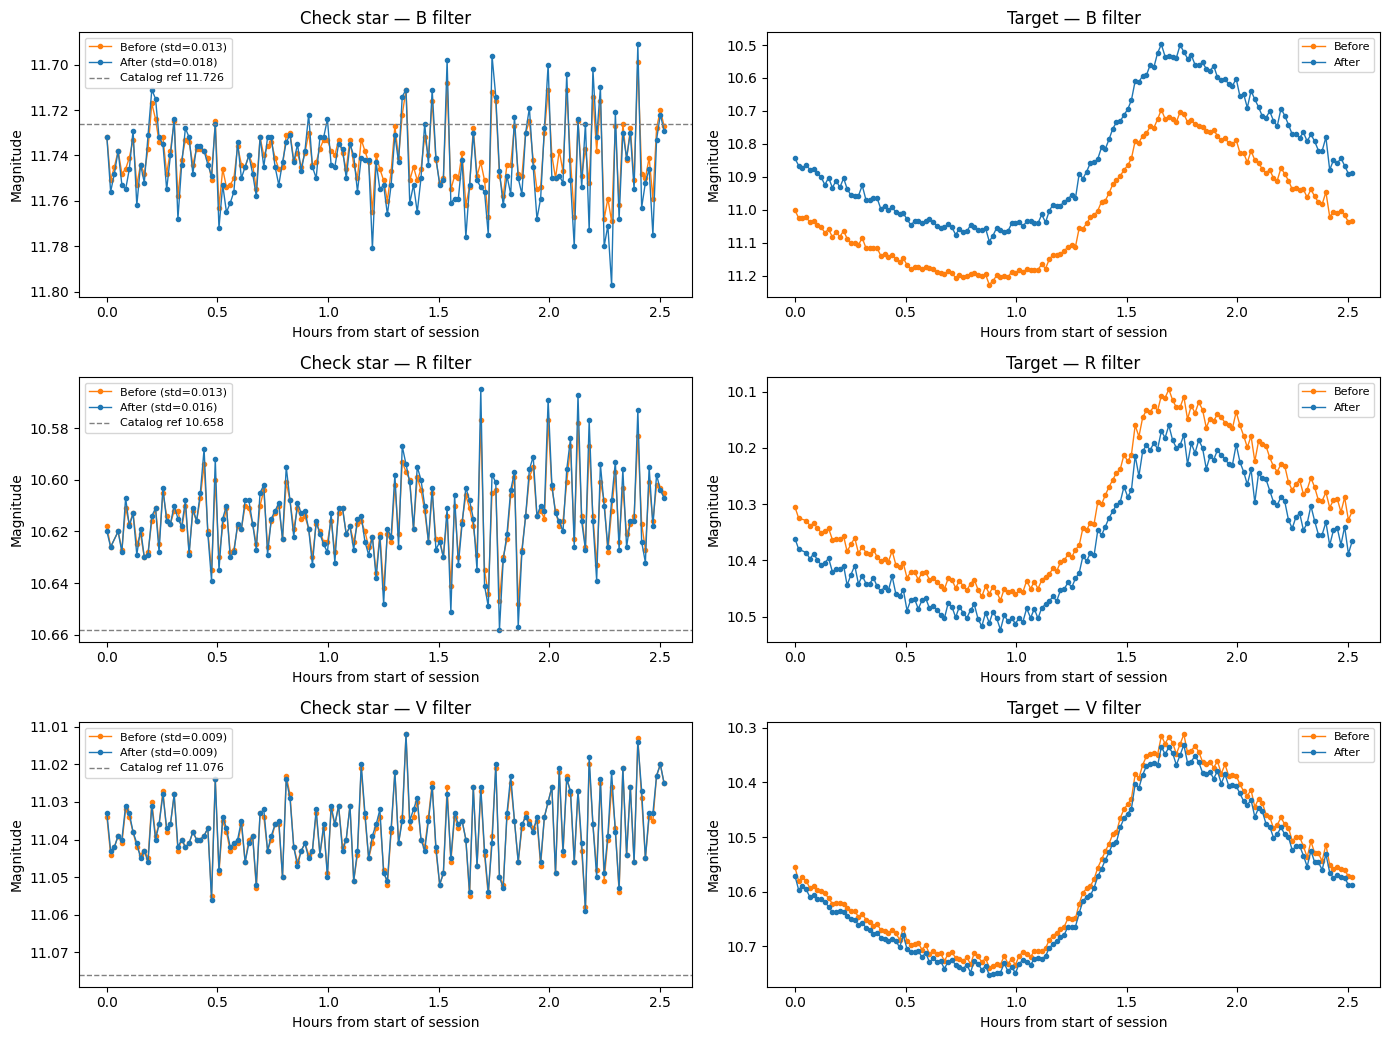

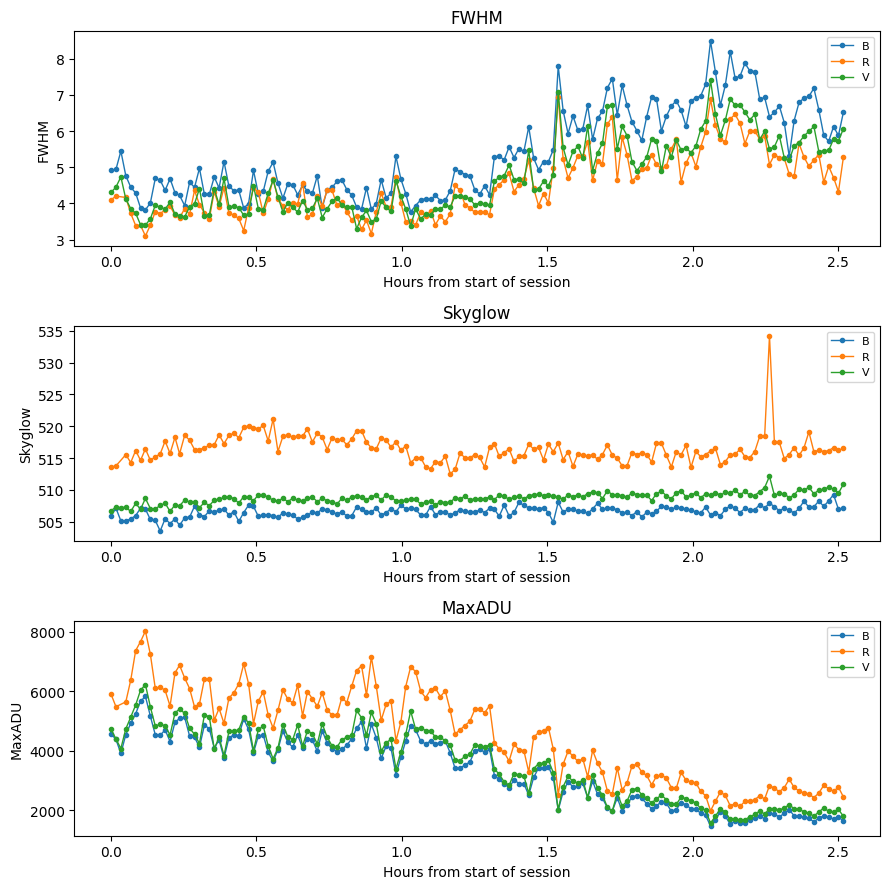

In [8]:
def plot_before_after(df_before, df_after=None):
    """Check star (accuracy/precision) and target (curve-shape gut-check) side by side, per filter.
    df_after=None (single-report mode) plots just the one session's curve on each axis."""
    filters = sorted(set(df_before["FILT"]) | (set(df_after["FILT"]) if df_after is not None else set()))
    fig, axes = plt.subplots(len(filters), 2, figsize=(14, 3.5 * len(filters)), squeeze=False)
    t0 = df_before["DATE"].min() if df_after is None else min(df_before["DATE"].min(), df_after["DATE"].min())

    for (ax_check, ax_target), filt in zip(axes, filters):
        gb = df_before[df_before["FILT"] == filt].sort_values("DATE")
        ga = df_after[df_after["FILT"] == filt].sort_values("DATE") if df_after is not None else None
        refmag = (gb if len(gb) else ga)["KREFMAG"].iloc[0]

        gb_label = f"{'Before' if ga is not None else 'Session'} (std={gb['KEFF'].std():.3f})"
        ax_check.plot((gb["DATE"] - t0) * 24.0, gb["KEFF"], "o-", ms=3, lw=1, color="tab:orange", label=gb_label)
        if ga is not None:
            ax_check.plot((ga["DATE"] - t0) * 24.0, ga["KEFF"], "o-", ms=3, lw=1, color="tab:blue",
                          label=f"After (std={ga['KEFF'].std():.3f})")
        ax_check.axhline(refmag, color="gray", ls="--", lw=1, label=f"Catalog ref {refmag:.3f}")
        ax_check.invert_yaxis()
        ax_check.set_title(f"Check star — {filt} filter")
        ax_check.set_xlabel("Hours from start of session")
        ax_check.set_ylabel("Magnitude")
        ax_check.legend(loc="best", fontsize=8)

        ax_target.plot((gb["DATE"] - t0) * 24.0, gb["MAG"], "o-", ms=3, lw=1, color="tab:orange",
                       label="Before" if ga is not None else "Session")
        if ga is not None:
            ax_target.plot((ga["DATE"] - t0) * 24.0, ga["MAG"], "o-", ms=3, lw=1, color="tab:blue", label="After")
        ax_target.invert_yaxis()
        ax_target.set_title(f"Target — {filt} filter")
        ax_target.set_xlabel("Hours from start of session")
        ax_target.set_ylabel("Magnitude")
        ax_target.legend(loc="best", fontsize=8)

    fig.tight_layout()
    return fig


plot_before_after(df_before, df_after);


def plot_diagnostics(df_before):
    """Image-quality diagnostics from the General Report (FWHM/Skyglow/Max ADU) -- session-level,
    not before/after, since both share the same underlying exposures."""
    metrics = ["FWHM", "Skyglow", "MaxADU"]
    filters = sorted(df_before["FILT"].unique())
    color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    colors = dict(zip(filters, color_cycle))
    t0 = df_before["DATE"].min()

    fig, axes = plt.subplots(len(metrics), 1, figsize=(9, 3 * len(metrics)), squeeze=False)
    for ax, metric in zip(axes[:, 0], metrics):
        for filt in filters:
            g = df_before[df_before["FILT"] == filt].sort_values("DATE")
            ax.plot((g["DATE"] - t0) * 24.0, g[metric], "o-", ms=3, lw=1, color=colors[filt], label=filt)
        ax.set_title(metric)
        ax.set_xlabel("Hours from start of session")
        ax.set_ylabel(metric)
        ax.legend(loc="best", fontsize=8)

    fig.tight_layout()
    return fig


plot_diagnostics(df_before);